# EDA: Survival Analysis Exploration

**Phase 1 — EDA & Data Understanding**

Survival analysis exploration of the time-to-threat prediction problem.

**Goals:**
- Kaplan-Meier survival curves (overall + stratified by key features)
- Nelson-Aalen cumulative hazard
- Censoring analysis: rate, distribution, relationship to features
- Log-rank tests for key feature stratifications

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

from lifelines import KaplanMeierFitter, NelsonAalenFitter
from lifelines.statistics import logrank_test

sns.set_theme(style="whitegrid", palette="muted")
FIGURES_DIR = Path("../reports/figures")
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

def save_fig(name: str) -> None:
    plt.gcf().savefig(FIGURES_DIR / f"{name}.png", dpi=150, bbox_inches="tight")

train = pd.read_csv("../data/raw/train.csv")

T = train["time_to_hit_hours"]
E = train["event"]  # 1 = hit, 0 = censored

print(f"Observations: {len(T)}")
print(f"Events (hit):   {E.sum()} ({E.mean():.1%})")
print(f"Censored:       {(1-E).sum()} ({(1-E).mean():.1%})")

Observations: 221
Events (hit):   69 (31.2%)
Censored:       152 (68.8%)


## 1. Overall Kaplan-Meier Survival Curve

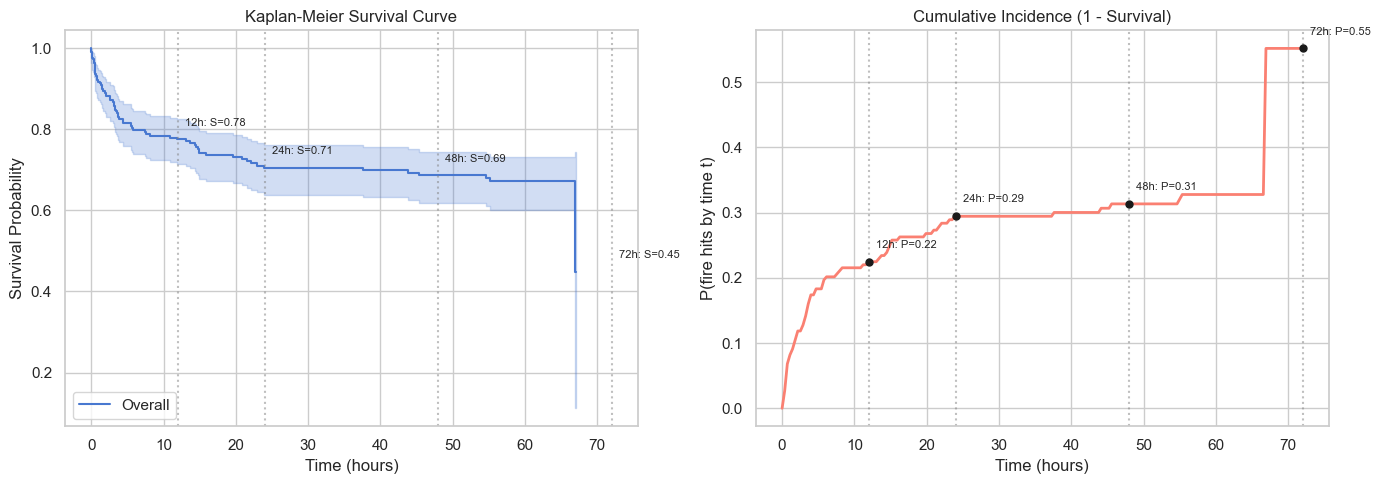


Survival probabilities at submission horizons:
  S(12h) = 0.7753  →  P(hit by 12h) = 0.2247
  S(24h) = 0.7056  →  P(hit by 24h) = 0.2944
  S(48h) = 0.6866  →  P(hit by 48h) = 0.3134
  S(72h) = 0.4481  →  P(hit by 72h) = 0.5519


In [2]:
kmf = KaplanMeierFitter()
kmf.fit(T, event_observed=E, label="Overall")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Survival function
kmf.plot_survival_function(ax=axes[0], ci_show=True)
axes[0].set_xlabel("Time (hours)")
axes[0].set_ylabel("Survival Probability")
axes[0].set_title("Kaplan-Meier Survival Curve")
# Mark submission horizons
for h in [12, 24, 48, 72]:
    axes[0].axvline(h, color="gray", ls=":", alpha=0.5)
    s_at_h = kmf.predict(h)
    axes[0].annotate(f"{h}h: S={s_at_h:.2f}", xy=(h, s_at_h), fontsize=8,
                     xytext=(5, 10), textcoords="offset points")

# Cumulative density (1 - S) = P(hit by time t)
times = np.linspace(0, 72, 200)
survival = kmf.predict(times)
axes[1].plot(times, 1 - survival, color="salmon", lw=2)
axes[1].set_xlabel("Time (hours)")
axes[1].set_ylabel("P(fire hits by time t)")
axes[1].set_title("Cumulative Incidence (1 - Survival)")
for h in [12, 24, 48, 72]:
    p = 1 - kmf.predict(h)
    axes[1].axvline(h, color="gray", ls=":", alpha=0.5)
    axes[1].plot(h, p, "ko", ms=5)
    axes[1].annotate(f"{h}h: P={p:.2f}", xy=(h, p), fontsize=8,
                     xytext=(5, 10), textcoords="offset points")

plt.tight_layout()
save_fig("kaplan_meier_overall")
plt.show()

print("\nSurvival probabilities at submission horizons:")
for h in [12, 24, 48, 72]:
    print(f"  S({h}h) = {kmf.predict(h):.4f}  →  P(hit by {h}h) = {1-kmf.predict(h):.4f}")

## 2. Nelson-Aalen Cumulative Hazard

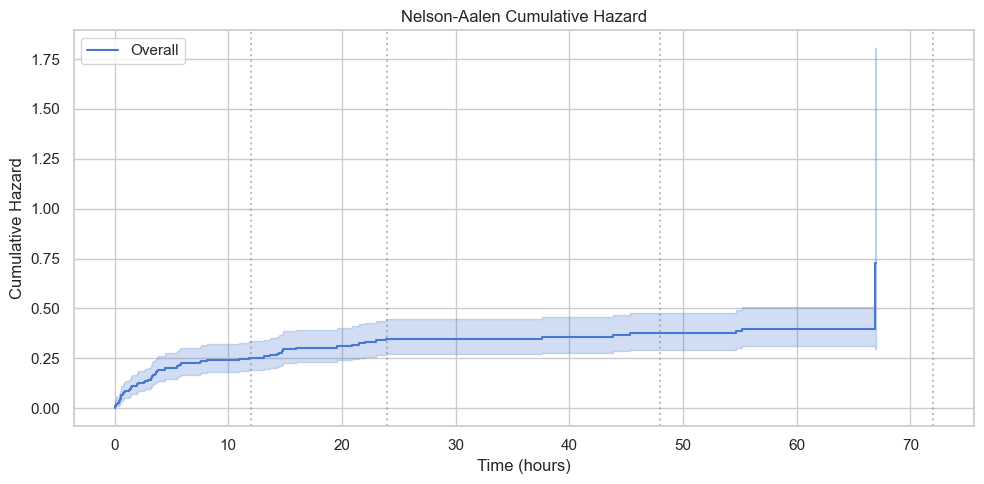

In [3]:
naf = NelsonAalenFitter()
naf.fit(T, event_observed=E, label="Overall")

fig, ax = plt.subplots(figsize=(10, 5))
naf.plot_cumulative_hazard(ax=ax, ci_show=True)
ax.set_xlabel("Time (hours)")
ax.set_ylabel("Cumulative Hazard")
ax.set_title("Nelson-Aalen Cumulative Hazard")
for h in [12, 24, 48, 72]:
    ax.axvline(h, color="gray", ls=":", alpha=0.5)

plt.tight_layout()
save_fig("nelson_aalen_cumulative_hazard")
plt.show()

## 3. Censoring Analysis

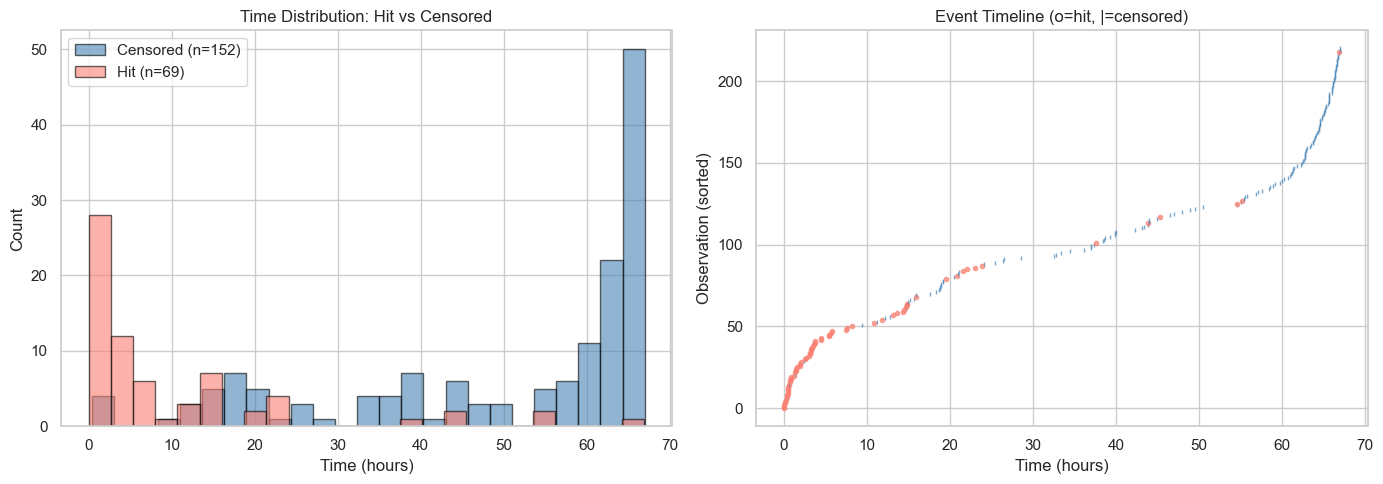


Censored time stats:
  Mean:   50.10h
  Median: 61.17h
  Most censored at ~66.4h+ (90th percentile)


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Censoring time distribution
censored = train[train["event"] == 0]["time_to_hit_hours"]
hit = train[train["event"] == 1]["time_to_hit_hours"]

axes[0].hist(censored, bins=25, alpha=0.6, color="steelblue", label=f"Censored (n={len(censored)})", edgecolor="black")
axes[0].hist(hit, bins=25, alpha=0.6, color="salmon", label=f"Hit (n={len(hit)})", edgecolor="black")
axes[0].set_xlabel("Time (hours)")
axes[0].set_ylabel("Count")
axes[0].set_title("Time Distribution: Hit vs Censored")
axes[0].legend()

# Event timeline
sorted_train = train.sort_values("time_to_hit_hours")
colors = sorted_train["event"].map({0: "steelblue", 1: "salmon"})
markers = sorted_train["event"].map({0: "|", 1: "o"})

for i, (_, row) in enumerate(sorted_train.iterrows()):
    color = "salmon" if row["event"] == 1 else "steelblue"
    marker = "o" if row["event"] == 1 else "|"
    axes[1].plot(row["time_to_hit_hours"], i, marker=marker, color=color, ms=3, alpha=0.7)

axes[1].set_xlabel("Time (hours)")
axes[1].set_ylabel("Observation (sorted)")
axes[1].set_title("Event Timeline (o=hit, |=censored)")

plt.tight_layout()
save_fig("censoring_analysis")
plt.show()

print(f"\nCensored time stats:")
print(f"  Mean:   {censored.mean():.2f}h")
print(f"  Median: {censored.median():.2f}h")
print(f"  Most censored at ~{censored.quantile(0.9):.1f}h+ (90th percentile)")

## 4. Stratified Kaplan-Meier Curves

Stratify by key features to identify which groups have different survival profiles.

In [5]:
def plot_km_stratified(df, col, n_groups=2, title=None):
    """Plot KM curves stratified by quantiles of a continuous feature."""
    fig, ax = plt.subplots(figsize=(10, 6))
    kmf = KaplanMeierFitter()

    # Create groups based on quantiles
    labels = [f"Q{i+1}" for i in range(n_groups)]
    try:
        df["_group"] = pd.qcut(df[col], n_groups, labels=labels, duplicates="drop")
    except ValueError:
        # Handle columns with too many duplicate values
        median_val = df[col].median()
        df["_group"] = np.where(df[col] <= median_val, "Low", "High")
        labels = ["Low", "High"]

    for label in df["_group"].unique():
        mask = df["_group"] == label
        kmf.fit(df.loc[mask, "time_to_hit_hours"],
                event_observed=df.loc[mask, "event"],
                label=f"{col}={label} (n={mask.sum()})")
        kmf.plot_survival_function(ax=ax, ci_show=False)

    # Log-rank test (first vs last group)
    groups = df["_group"].unique()
    if len(groups) >= 2:
        g1 = df[df["_group"] == groups[0]]
        g2 = df[df["_group"] == groups[-1]]
        result = logrank_test(g1["time_to_hit_hours"], g2["time_to_hit_hours"],
                             event_observed_A=g1["event"], event_observed_B=g2["event"])
        pval = result.p_value
        ax.set_title(f"{title or col}\nLog-rank p={pval:.4f} {'***' if pval < 0.001 else '**' if pval < 0.01 else '*' if pval < 0.05 else 'ns'}")
    else:
        ax.set_title(title or col)

    ax.set_xlabel("Time (hours)")
    ax.set_ylabel("Survival Probability")
    for h in [12, 24, 48, 72]:
        ax.axvline(h, color="gray", ls=":", alpha=0.3)
    ax.legend()

    df.drop(columns=["_group"], inplace=True)
    return fig

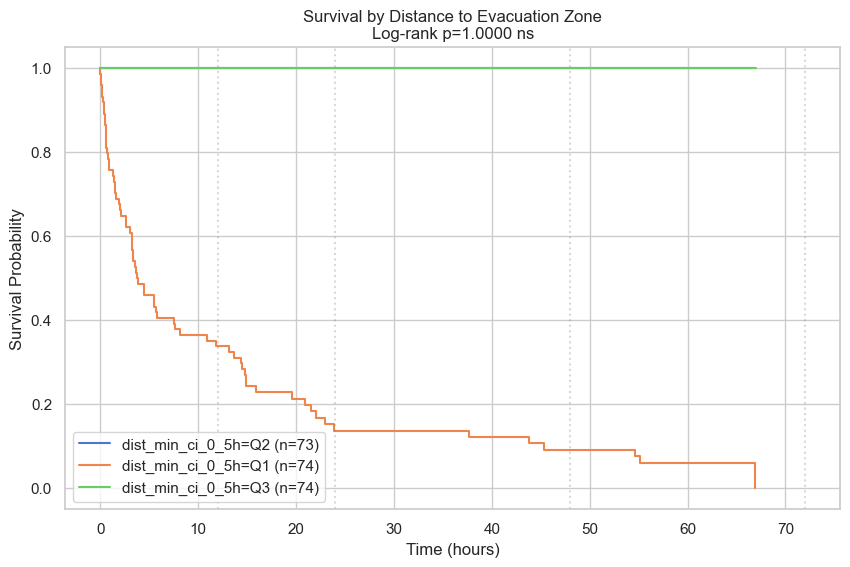

In [6]:
# Stratify by minimum distance to evacuation zone
fig = plot_km_stratified(train.copy(), "dist_min_ci_0_5h", n_groups=3,
                         title="Survival by Distance to Evacuation Zone")
save_fig("km_by_distance")
plt.show()

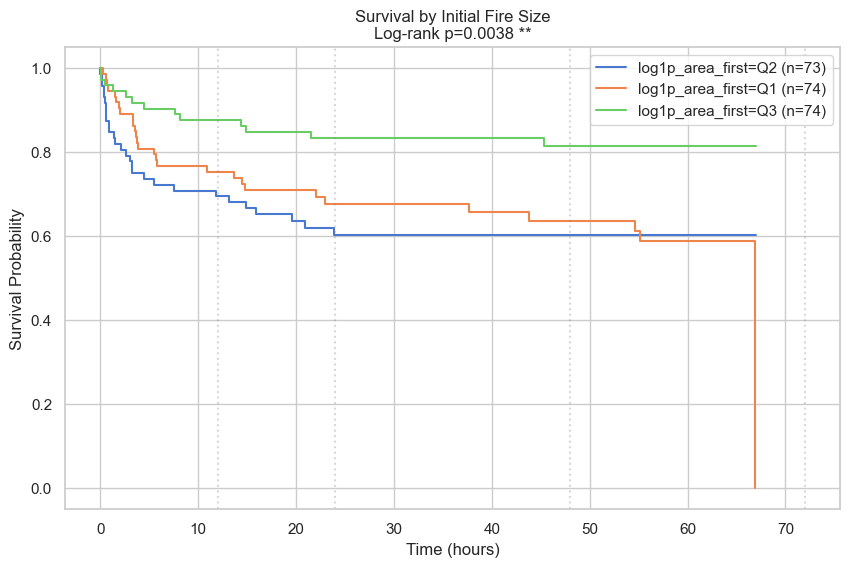

In [7]:
# Stratify by initial fire area
fig = plot_km_stratified(train.copy(), "log1p_area_first", n_groups=3,
                         title="Survival by Initial Fire Size")
save_fig("km_by_fire_size")
plt.show()

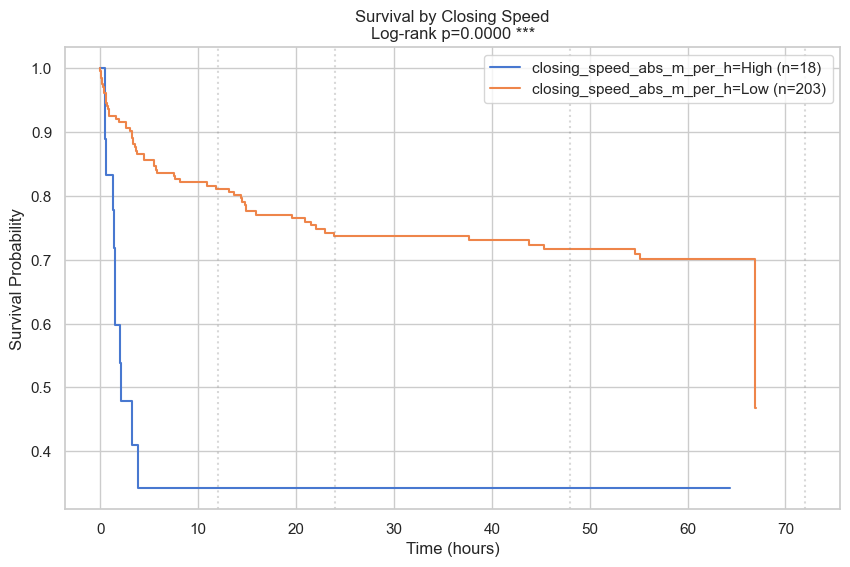

In [8]:
# Stratify by closing speed
fig = plot_km_stratified(train.copy(), "closing_speed_abs_m_per_h", n_groups=2,
                         title="Survival by Closing Speed")
save_fig("km_by_closing_speed")
plt.show()

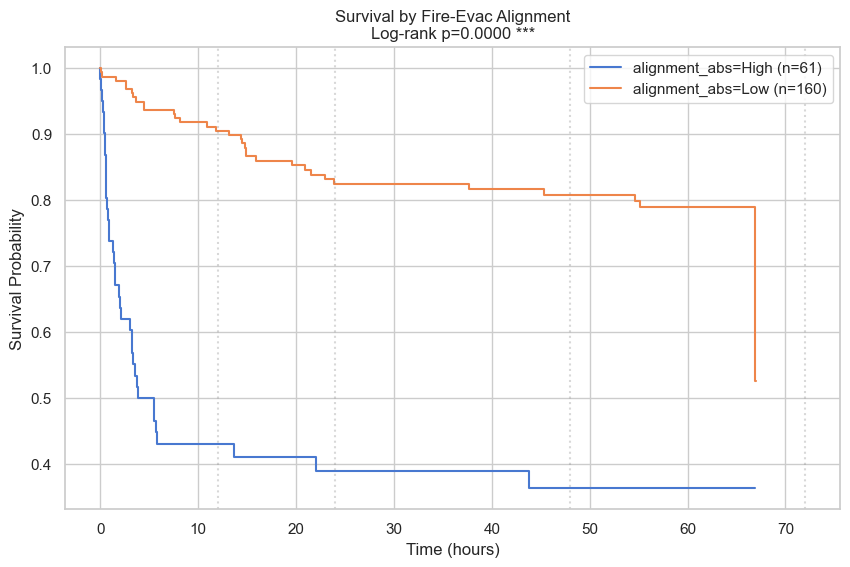

In [9]:
# Stratify by alignment
fig = plot_km_stratified(train.copy(), "alignment_abs", n_groups=2,
                         title="Survival by Fire-Evac Alignment")
save_fig("km_by_alignment")
plt.show()

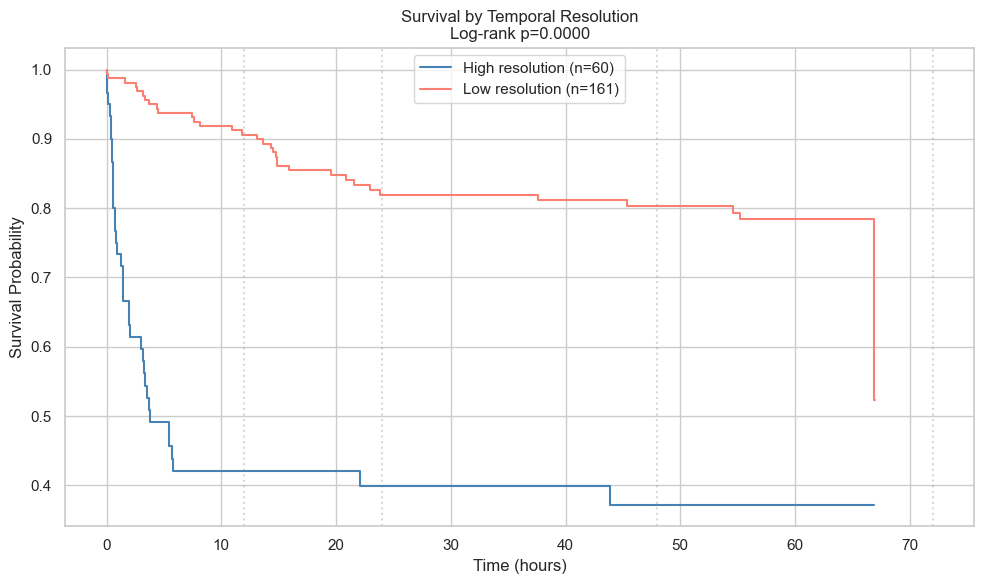

In [10]:
# Stratify by temporal resolution flag
fig, ax = plt.subplots(figsize=(10, 6))
kmf = KaplanMeierFitter()

for flag, label, color in [(0, "High resolution", "steelblue"), (1, "Low resolution", "salmon")]:
    mask = train["low_temporal_resolution_0_5h"] == flag
    kmf.fit(train.loc[mask, "time_to_hit_hours"],
            event_observed=train.loc[mask, "event"],
            label=f"{label} (n={mask.sum()})")
    kmf.plot_survival_function(ax=ax, ci_show=False, color=color)

# Log-rank test
g1 = train[train["low_temporal_resolution_0_5h"] == 0]
g2 = train[train["low_temporal_resolution_0_5h"] == 1]
result = logrank_test(g1["time_to_hit_hours"], g2["time_to_hit_hours"],
                     event_observed_A=g1["event"], event_observed_B=g2["event"])

ax.set_xlabel("Time (hours)")
ax.set_ylabel("Survival Probability")
ax.set_title(f"Survival by Temporal Resolution\nLog-rank p={result.p_value:.4f}")
ax.legend()
for h in [12, 24, 48, 72]:
    ax.axvline(h, color="gray", ls=":", alpha=0.3)

plt.tight_layout()
save_fig("km_by_temporal_resolution")
plt.show()

## 5. Log-Rank Test Summary

In [11]:
# Systematic log-rank tests for all features (median split)
feature_cols = [c for c in train.columns if c not in ["event_id", "time_to_hit_hours", "event"]]

logrank_results = []
for col in feature_cols:
    median_val = train[col].median()
    low = train[train[col] <= median_val]
    high = train[train[col] > median_val]

    if len(low) < 5 or len(high) < 5:
        continue

    result = logrank_test(
        low["time_to_hit_hours"], high["time_to_hit_hours"],
        event_observed_A=low["event"], event_observed_B=high["event"]
    )
    logrank_results.append({
        "feature": col,
        "test_statistic": round(result.test_statistic, 4),
        "p_value": result.p_value,
        "significant": "*" if result.p_value < 0.05 else "",
    })

lr_df = pd.DataFrame(logrank_results).sort_values("p_value")
print(f"Features with significant survival differences (p < 0.05): {(lr_df['p_value'] < 0.05).sum()}/{len(lr_df)}")
print()
lr_df

Features with significant survival differences (p < 0.05): 28/32



,feature,test_statistic,p_value,significant
16,dist_min_ci_0_5h,102.8601,3.596750e-24,*
0,num_perimeters_0_5h,59.3909,1.292679e-14,*
26,alignment_abs,59.3909,1.292679e-14,*
1,dt_first_last_0_5h,59.3909,1.292679e-14,*
12,centroid_displacement_m,58.7058,1.830969e-14,*
13,centroid_speed_m_per_h,58.7058,1.830969e-14,*
14,spread_bearing_deg,58.7058,1.830969e-14,*
7,log1p_growth,53.6645,2.378221e-13,*
11,radial_growth_rate_m_per_h,53.6645,2.378221e-13,*
10,radial_growth_m,53.6645,2.378221e-13,*


## 6. Key Findings

### Survival Characteristics
- **High censoring rate (68.8%)** — most fires never reach the evacuation zone within 72h
- Survival curve drops steeply in the first ~15h, then flattens
- Most hit events occur early (within the first 24h)

### Stratification Insights
- **Distance** is the strongest stratifier — closer fires hit much sooner
- **Closing speed** separates survival curves clearly
- **Alignment** matters — fires moving toward evac zones hit faster
- **Fire size** has moderate stratification power

### Implications for Modeling
- Survival models (Cox PH, RSF) are well-suited for this problem
- Distance and closing speed features should be primary predictors
- The submission requires P(hit by T) = 1 - S(T), which maps directly to survival analysis output
- High censoring rate means models must handle right-censored data properly